# Mini-Projeto Avaliativo — Pipeline do MNIST

Notebook organizado para atender às diretrizes do **Mini-Projeto Avaliativo – Módulo 2**.

**Objetivo:** construir, treinar, validar, comparar e estressar um pipeline preditivo multiclasse ponta a ponta para dígitos manuscritos (`mnist_784`).

**Modelos comparados:** KNN · Random Forest · MLP (Keras)

**Desafios extras:** robustez OOD (classes 4 e 9 ocultadas) · inferência com imagens autorais

**Reprodutibilidade:** `random_state=42` e seeds do TensorFlow em todo o pipeline.


In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
np.random.seed(42)
tf.random.set_seed(42)

project_root = Path.cwd()
if project_root.name.lower() == "notebooks":
    project_root = project_root.parent

# Garante import do módulo compartilhado src/
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.preprocess import preprocess_image_to_mnist, image_to_feature_vector

data_dir = project_root / "data"
models_dir = project_root / "models"
docs_dir = project_root / "docs"

models_dir.mkdir(parents=True, exist_ok=True)
docs_dir.mkdir(parents=True, exist_ok=True)

print(f"Projeto raiz: {project_root.name}")
print(f"Pasta de dados: ./data")
print(f"Pasta de modelos: ./models")
print(f"TensorFlow: {tf.__version__}")


Projeto raiz: Mini Projeto
Pasta de dados: ./data
Pasta de modelos: ./models
TensorFlow: 2.21.0


# Fase 1 — Carregamento e análise exploratória (EDA)

O dataset MNIST contém **70.000 imagens** em tons de cinza, cada uma com **28 × 28 pixels** (784 features após vetorização), representando dígitos manuscritos de 0 a 9.

Nesta fase:
1. Carregamos `mnist_784` via OpenML
2. Inspecionamos dimensionalidade e balanceamento de classes
3. Exibimos uma grade 2 × 5 com um exemplo de cada dígito


Baixando / carregando o MNIST...
Dimensionalidade de X: (70000, 784)
Dimensionalidade de y: (70000,)


,quantidade
0,6903
1,7877
2,6990
3,7141
4,6824
5,6313
6,6876
7,7293
8,6825
9,6958


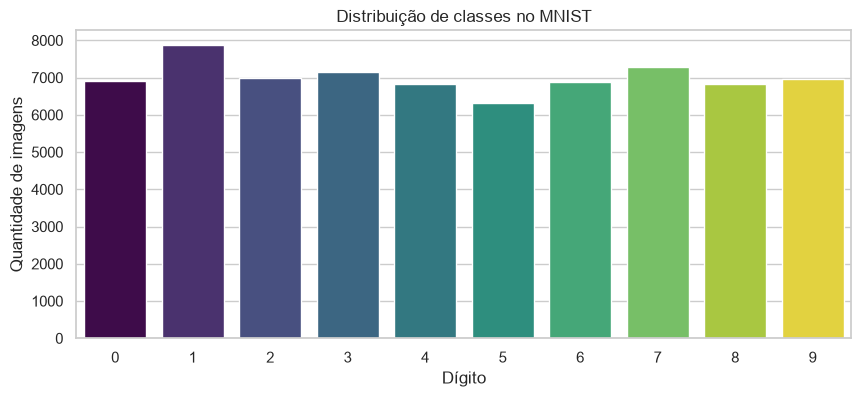

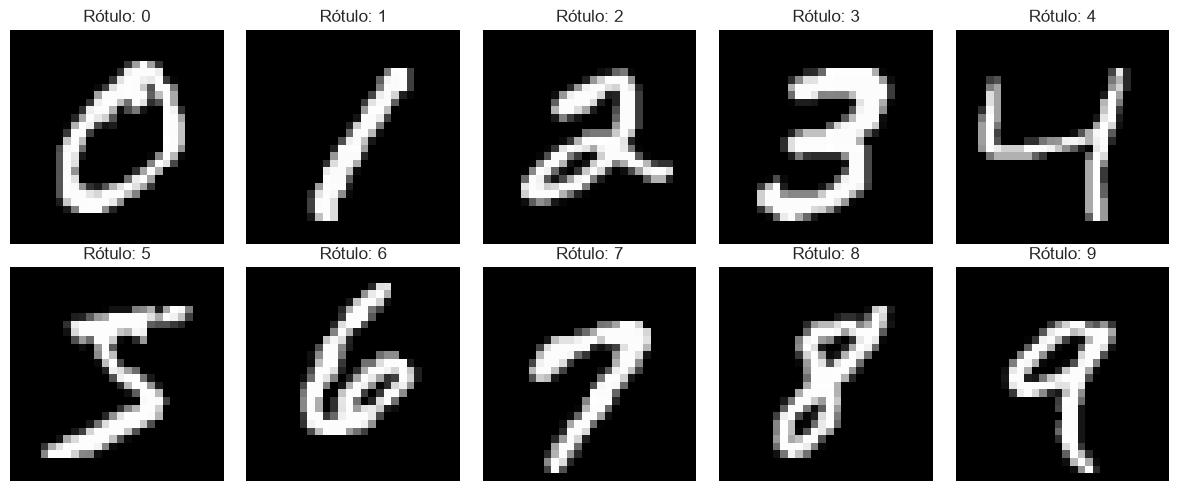

In [2]:
print("Baixando / carregando o MNIST...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int64)

print(f"Dimensionalidade de X: {X.shape}")
print(f"Dimensionalidade de y: {y.shape}")

class_counts = pd.Series(y).value_counts().sort_index()
display(class_counts.to_frame(name="quantidade"))

plt.figure(figsize=(10, 4))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    palette="viridis",
    hue=class_counts.index,
    legend=False,
)
plt.title("Distribuição de classes no MNIST")
plt.xlabel("Dígito")
plt.ylabel("Quantidade de imagens")
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for digit in range(10):
    idx = np.where(y == digit)[0][0]
    axes[digit].imshow(X[idx].reshape(28, 28), cmap="gray")
    axes[digit].set_title(f"Rótulo: {digit}")
    axes[digit].axis("off")
plt.tight_layout()
plt.show()


## Interpretação técnica da estrutura dos dados

- Cada imagem é originalmente uma malha **28 × 28**, mas neste problema é tratada como vetor **1D com 784 features**.
- Cada feature representa a intensidade de um pixel, na faixa **0 a 255**.
- A base é praticamente balanceada entre as 10 classes, o que favorece o uso de métricas ponderadas (weighted) na comparação entre modelos.
- A representação achatada é adequada e consistente com o requisito de comparar algoritmos clássicos e rede neural MLP.


# Fase 2 — Pré-processamento e divisão dos dados

Divisão **estratificada** em três conjuntos (conforme diretrizes):

| Conjunto   | Proporção | Uso |
|------------|-----------|-----|
| Treino     | 70 %      | Ajuste dos parâmetros |
| Validação  | 10 %      | Monitoramento da MLP e diagnóstico |
| Teste      | 20 %      | Avaliação final (nunca visto no treino) |

A normalização (`/ 255.0`) é aplicada **após** o split → evita qualquer forma de data leakage de escala.


In [3]:
# 1º split: 80 % (treino+val) / 20 % teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2º split: do temp, 12.5 % vira validação → ~10 % do total original
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

X_train_norm = X_train / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0

print(f"Treino:     {X_train_norm.shape[0]:>6} amostras ({X_train_norm.shape[0]/len(y)*100:.1f} %)")
print(f"Validação:  {X_val_norm.shape[0]:>6} amostras ({X_val_norm.shape[0]/len(y)*100:.1f} %)")
print(f"Teste:      {X_test_norm.shape[0]:>6} amostras ({X_test_norm.shape[0]/len(y)*100:.1f} %)")
print(f"Valor mínimo após normalização: {X_train_norm.min():.1f}")
print(f"Valor máximo após normalização: {X_train_norm.max():.1f}")

test_distribution = (
    pd.Series(y_test).value_counts(normalize=True).sort_index().mul(100).round(2)
)
display(test_distribution.to_frame(name="percentual_no_teste"))


Treino:      49000 amostras (70.0 %)
Validação:    7000 amostras (10.0 %)
Teste:       14000 amostras (20.0 %)
Valor mínimo após normalização: 0.0
Valor máximo após normalização: 1.0


,percentual_no_teste
0,9.86
1,11.25
2,9.99
3,10.20
4,9.75
5,9.02
6,9.82
7,10.42
8,9.75
9,9.94


## Justificativa da normalização

1. **Estabilidade numérica e convergência**: redes neurais treinadas por gradiente convergem de forma mais estável com features em pequena magnitude ([0, 1]).
2. **Consistência de distâncias**: KNN depende diretamente de distância euclidiana; manter pixels em `[0, 1]` evita escalas artificialmente grandes.
3. **Ausência de leakage**: a divisão por 255 é uma transformação determinística e global (não usa estatísticas do conjunto de teste).


# Fase 3 — Implementação e treinamento dos 3 modelos

Serão comparados:

- **KNN** — `n_neighbors=3`, `weights='distance'`
- **Random Forest** — `n_estimators=100`, `max_depth=15`
- **MLP (Keras)** — 128 → 64 → 10, `epochs=10`, `batch_size=32`, validação explícita


In [4]:
def build_mlp() -> Sequential:
    model = Sequential(
        [
            Input(shape=(784,)),
            Dense(128, activation="relu"),
            Dense(64, activation="relu"),
            Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


models: dict = {}
train_times: dict = {}
predict_times: dict = {}
predictions: dict = {}
probabilities: dict = {}

# --- KNN ---
knn_model = KNeighborsClassifier(n_neighbors=3, weights="distance")
start = time.perf_counter()
knn_model.fit(X_train_norm, y_train)
train_times["KNN"] = time.perf_counter() - start
models["KNN"] = knn_model

# --- Random Forest ---
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
)
start = time.perf_counter()
rf_model.fit(X_train_norm, y_train)
train_times["Random Forest"] = time.perf_counter() - start
models["Random Forest"] = rf_model

# --- MLP (usa conjunto de validação explícito) ---
mlp_model = build_mlp()
start = time.perf_counter()
history = mlp_model.fit(
    X_train_norm,
    y_train,
    validation_data=(X_val_norm, y_val),
    epochs=10,
    batch_size=32,
    verbose=1,
)
train_times["MLP"] = time.perf_counter() - start
models["MLP"] = mlp_model

# Inferência no conjunto de teste
for model_name, model in models.items():
    start = time.perf_counter()
    if model_name == "MLP":
        y_prob = model.predict(X_test_norm, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
    else:
        y_pred = model.predict(X_test_norm)
        y_prob = model.predict_proba(X_test_norm)
    predict_times[model_name] = time.perf_counter() - start
    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob

print("Treinamento concluído.")
for model_name in models:
    print(
        f"{model_name}: treinamento = {train_times[model_name]:.2f}s | "
        f"predição = {predict_times[model_name]:.2f}s"
    )


Epoch 1/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9260 - loss: 0.2520 - val_accuracy: 0.9496 - val_loss: 0.1602
Epoch 2/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9688 - loss: 0.1034 - val_accuracy: 0.9609 - val_loss: 0.1262
Epoch 3/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9787 - loss: 0.0699 - val_accuracy: 0.9683 - val_loss: 0.1045
Epoch 4/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9843 - loss: 0.0504 - val_accuracy: 0.9709 - val_loss: 0.0922
Epoch 5/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9879 - loss: 0.0389 - val_accuracy: 0.9729 - val_loss: 0.0946
Epoch 6/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9904 - loss: 0.0303 - val_accuracy: 0.9737 - val_loss: 0.1018
Epoch 7/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9920 - loss: 0.0255 - val_accuracy: 0.9739 - val_loss: 0.1084
Epoch 8/10
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9931 - loss: 0.0203 - 

## Justificativa dos hiperparâmetros escolhidos

### KNN
- `n_neighbors=3`: reduz excesso de suavização e preserva vizinhanças locais importantes para padrões caligráficos.
- `weights='distance'`: dá maior peso aos vizinhos mais próximos, coerente com similaridade visual.

### Random Forest
- `n_estimators=100`: ensemble robusto sem custo excessivo.
- `max_depth=15`: controla sobreajuste em um espaço com 784 atributos.

### MLP
- Arquitetura 128-64-10: capacidade suficiente para o MNIST sem overfitting agressivo.
- `epochs=10` e `batch_size=32`: equilíbrio entre convergência e tempo de treino.
- Validação explícita (`X_val` / `y_val`) para monitorar generalização durante o treino.


# Fase 4 — Avaliação comparativa de desempenho

Para cada modelo no **conjunto de teste independente**:
- Matriz de confusão 10 × 10 (heatmap)
- Accuracy, Precision / Recall / F1 **weighted**
- Tempos de treino e de predição

O melhor modelo empírico é escolhido pelo maior **F1-Score weighted**.


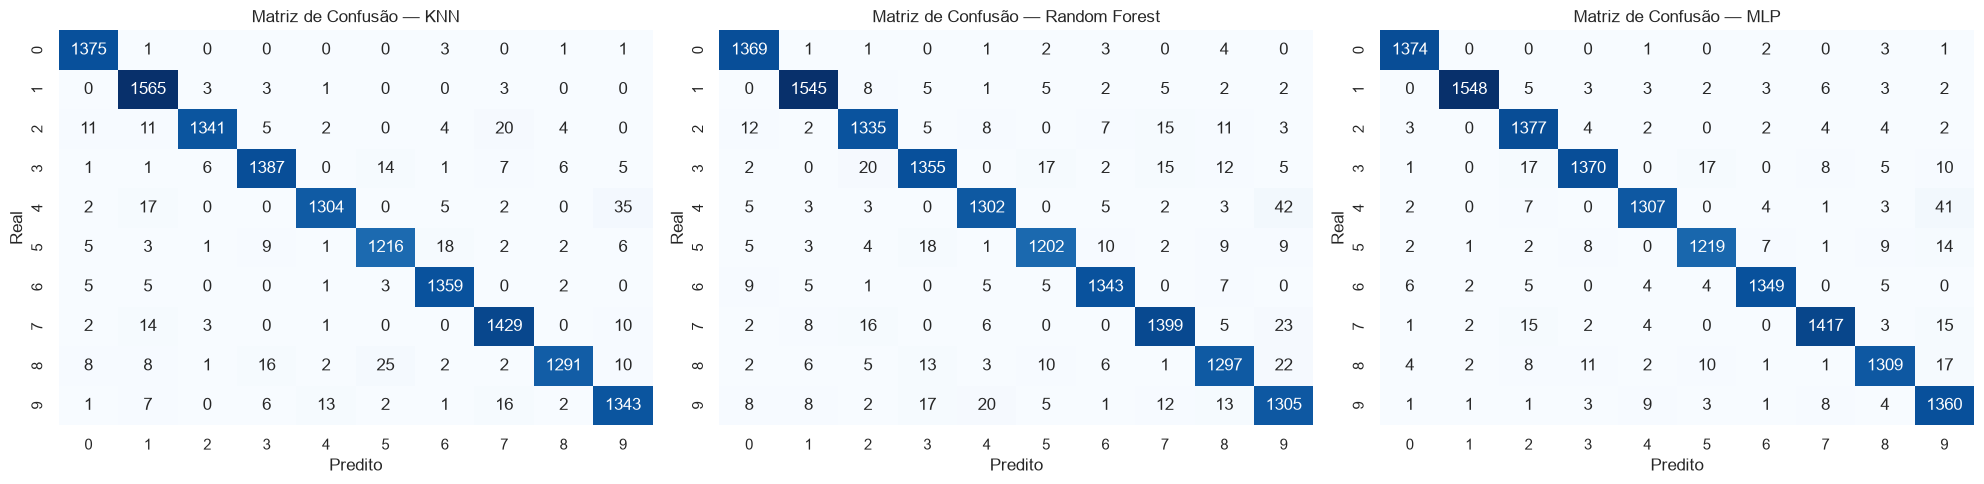

,modelo,acuracia,precisao_weighted,revocacao_weighted,f1_weighted,tempo_treino_s,tempo_predicao_s
0,MLP,97.36%,97.39%,97.36%,97.36%,25.68,0.8443
1,KNN,97.21%,97.24%,97.21%,97.21%,0.01,21.9701
2,Random Forest,96.09%,96.09%,96.09%,96.08%,3.92,0.2331


Melhor modelo empírico nesta execução: MLP


In [5]:
metric_rows = []

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for axis, (model_name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=range(10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis)
    axis.set_title(f"Matriz de Confusão — {model_name}")
    axis.set_xlabel("Predito")
    axis.set_ylabel("Real")

    metric_rows.append(
        {
            "modelo": model_name,
            "acuracia": accuracy_score(y_test, y_pred),
            "precisao_weighted": precision_score(y_test, y_pred, average="weighted"),
            "revocacao_weighted": recall_score(y_test, y_pred, average="weighted"),
            "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
            "tempo_treino_s": train_times[model_name],
            "tempo_predicao_s": predict_times[model_name],
        }
    )

plt.tight_layout()
plt.show()

metrics_df = (
    pd.DataFrame(metric_rows)
    .sort_values("f1_weighted", ascending=False)
    .reset_index(drop=True)
)
display(
    metrics_df.style.format(
        {
            "acuracia": "{:.2%}",
            "precisao_weighted": "{:.2%}",
            "revocacao_weighted": "{:.2%}",
            "f1_weighted": "{:.2%}",
            "tempo_treino_s": "{:.2f}",
            "tempo_predicao_s": "{:.4f}",
        }
    )
)

best_model_name = metrics_df.loc[0, "modelo"]
best_model = models[best_model_name]
print(f"Melhor modelo empírico nesta execução: {best_model_name}")


## Conclusão técnica da comparação

A escolha do melhor modelo é **estritamente empírica** (maior F1 weighted no teste).

Em geral, no MNIST:
- **KNN** costuma ser muito competitivo, porém caro em inferência.
- **Random Forest** é eficiente e robusta, mas frequentemente fica atrás dos outros dois.
- **MLP** combina boa acurácia com inferência rápida — adequada para a aplicação desktop.

A etapa de imagens autorais usa o **melhor modelo medido nesta execução**.


# Fase 5 — Estresse e robustez (OOD com classes ocultadas)

**Procedimento:**
1. Remover as classes **4** e **9** do conjunto de treino.
2. Retreinar uma MLP apenas com as 8 classes restantes.
3. Avaliar exclusivamente nas amostras de teste das classes 4 e 9 (OOD).
4. Comparar também o comportamento do modelo original (treinado com todas as classes) no mesmo subset OOD.

Classificadores “fechados” (softmax / vote) **sempre** atribuem uma das classes conhecidas — não possuem rejeição nativa. O objetivo é evidenciar esse comportamento.


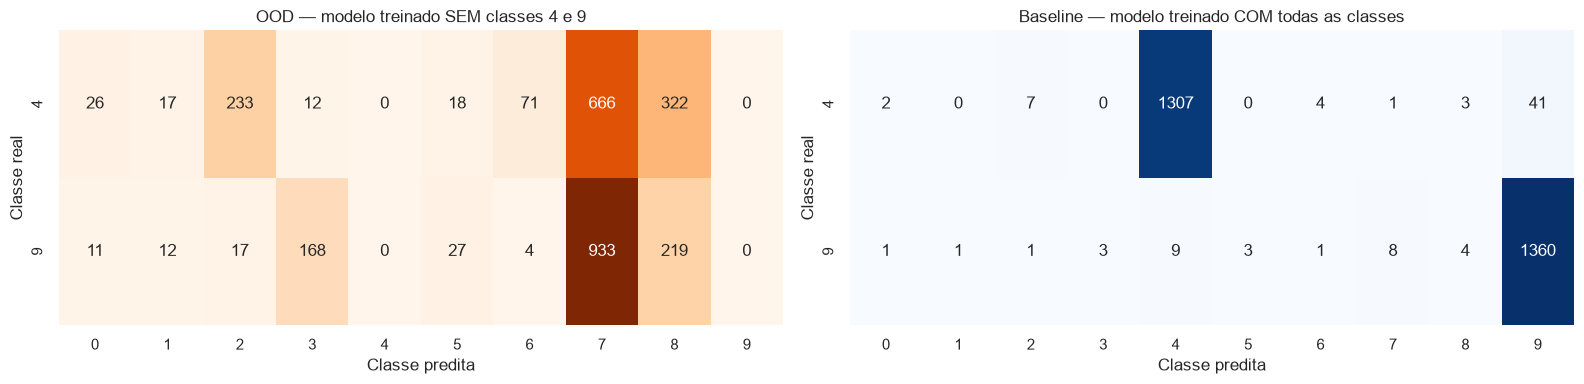

Amostras OOD avaliadas: 2756
Acurácia do baseline (modelo completo) no subset 4/9: 96.77%
Modelo OOD: taxa de predições forçadas em classes conhecidas = 100 % (não existe classe de rejeição).


In [6]:
# --- Treino mascarado (sem 4 e 9) ---
ood_mask_train = (y_train != 4) & (y_train != 9)
X_train_masked = X_train_norm[ood_mask_train]
y_train_masked = y_train[ood_mask_train]

ood_model = build_mlp()
_ = ood_model.fit(
    X_train_masked,
    y_train_masked,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=0,
)

# --- Subset OOD no teste ---
ood_mask_test = (y_test == 4) | (y_test == 9)
X_test_ood = X_test_norm[ood_mask_test]
y_test_ood = y_test[ood_mask_test]

# Predições do modelo OOD (nunca viu 4 nem 9)
ood_prob = ood_model.predict(X_test_ood, verbose=0)
ood_pred = np.argmax(ood_prob, axis=1)

# Predições do modelo original (viu todas as classes) — baseline
baseline_prob = mlp_model.predict(X_test_ood, verbose=0)
baseline_pred = np.argmax(baseline_prob, axis=1)

# Matriz filtrada: linhas = classes reais 4 e 9
ood_cm = confusion_matrix(y_test_ood, ood_pred, labels=range(10))
ood_cm_filtered = ood_cm[[4, 9], :]

baseline_cm = confusion_matrix(y_test_ood, baseline_pred, labels=range(10))
baseline_cm_filtered = baseline_cm[[4, 9], :]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.heatmap(
    ood_cm_filtered,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    xticklabels=list(range(10)),
    yticklabels=[4, 9],
    ax=axes[0],
)
axes[0].set_title("OOD — modelo treinado SEM classes 4 e 9")
axes[0].set_xlabel("Classe predita")
axes[0].set_ylabel("Classe real")

sns.heatmap(
    baseline_cm_filtered,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=list(range(10)),
    yticklabels=[4, 9],
    ax=axes[1],
)
axes[1].set_title("Baseline — modelo treinado COM todas as classes")
axes[1].set_xlabel("Classe predita")
axes[1].set_ylabel("Classe real")
plt.tight_layout()
plt.show()

print(f"Amostras OOD avaliadas: {len(y_test_ood)}")
print(
    f"Acurácia do baseline (modelo completo) no subset 4/9: "
    f"{accuracy_score(y_test_ood, baseline_pred):.2%}"
)
print(
    "Modelo OOD: taxa de predições forçadas em classes conhecidas = 100 % "
    "(não existe classe de rejeição)."
)


## Interpretação do desafio OOD

Quando um classificador multiclasse é exposto a padrões fora do domínio de treino, ele **não “sabe que não sabe”**: a camada softmax (ou o voto majoritário) sempre devolve uma das classes vistas no treino.

No experimento:
- O modelo treinado sem 4 e 9 redistribui as amostras OOD entre as 8 classes restantes (confusões típicas: 4→9/7/1, 9→4/7/3, etc.).
- O baseline (treinado com todas as classes) recupera boa parte da acurácia nesse subset, confirmando que o padrão visual de 4 e 9 é aprendível quando presente no treino.

Isso motiva, em produção, mecanismos de rejeição (limiar de confiança, OpenMax, energy-based OOD, etc.).


# Fase 5.3 — Inferência com imagens manuscritas próprias

O pré-processamento utiliza o módulo compartilhado `src.preprocess`, alinhado às diretrizes:

1. Escala de cinza  
2. Otsu + inversão  
3. Bounding box  
4. Escala proporcional (maior lado ≈ 20 px)  
5. Centralização em 28 × 28  
6. Normalização `[0, 1]`

> **Nota:** `data/python.png` é o logo da interface desktop e **não** é uma amostra de dígito; o pipeline o ignora automaticamente se o traço for inválido ou o arquivo for filtrado pela extensão de interesse.


Imagens autorais de dígitos encontradas: 16


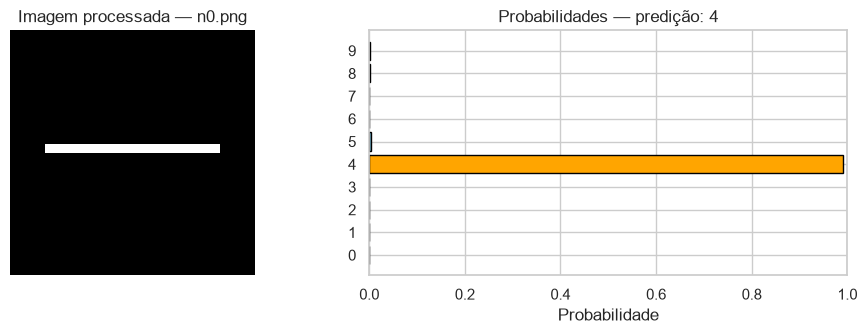

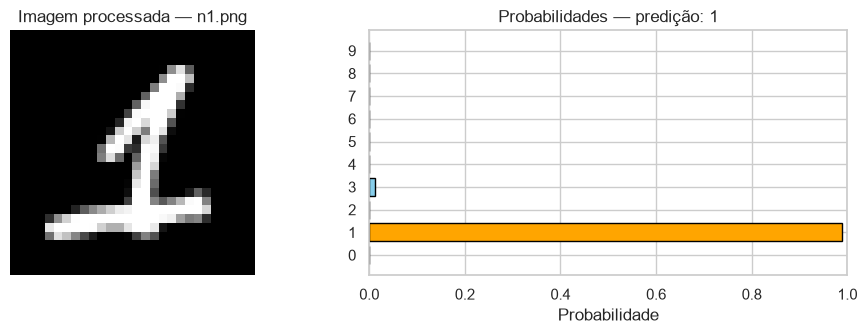

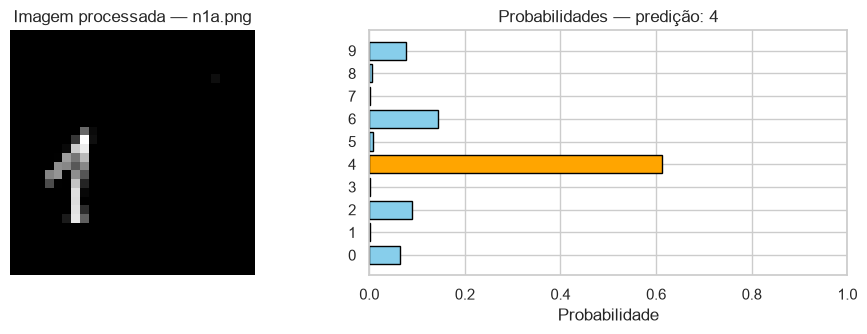

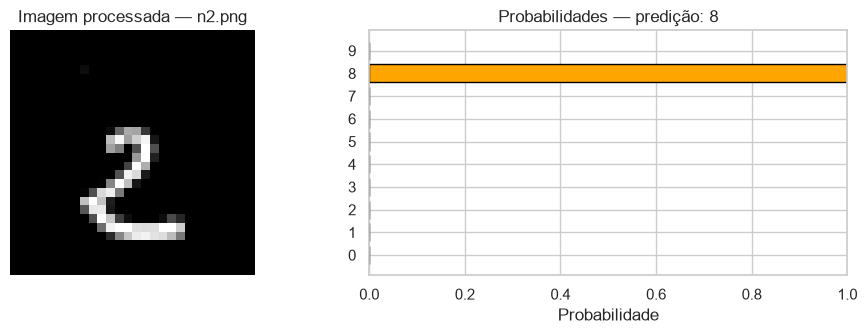

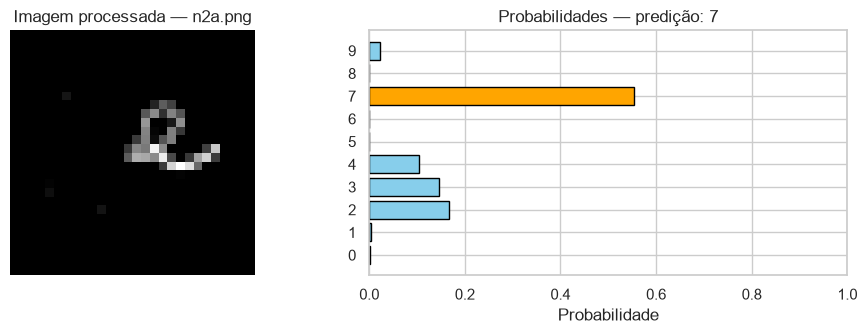

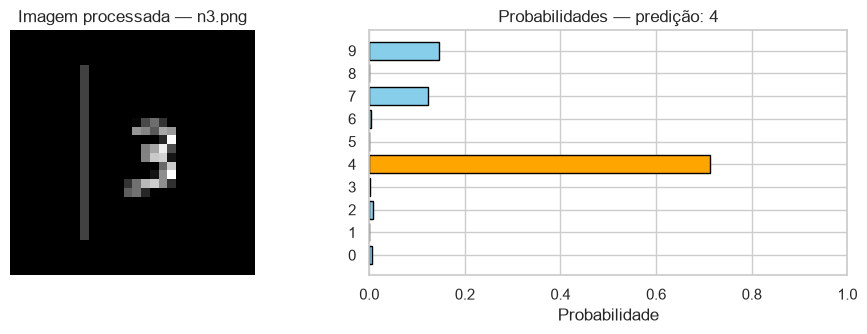

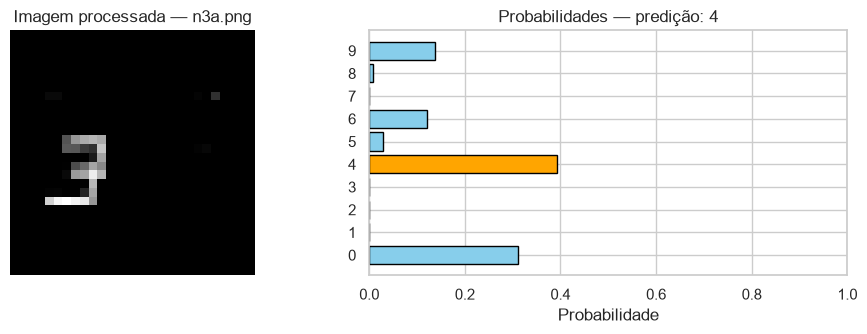

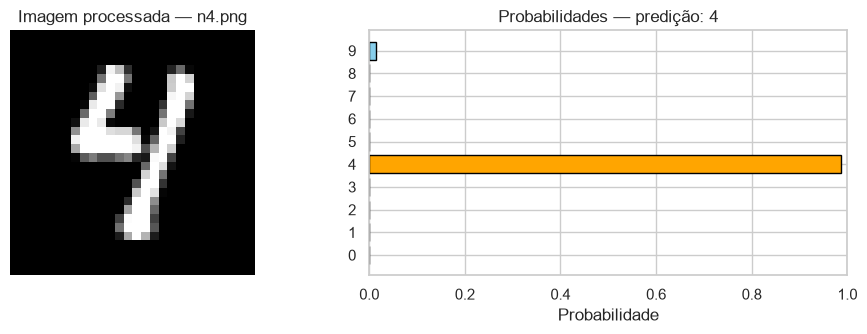

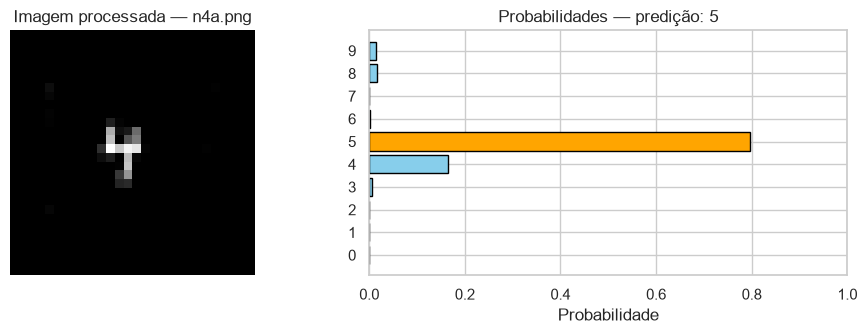

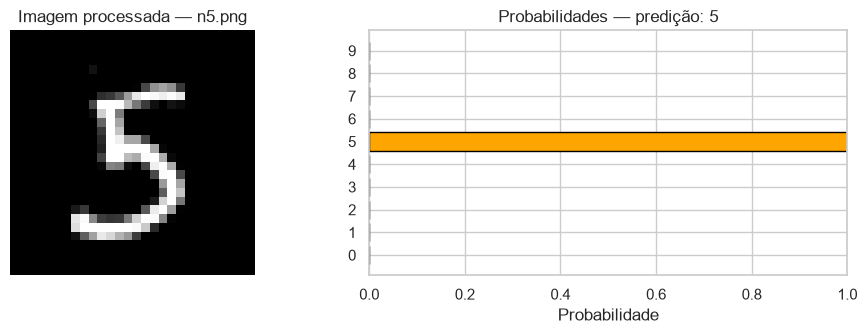

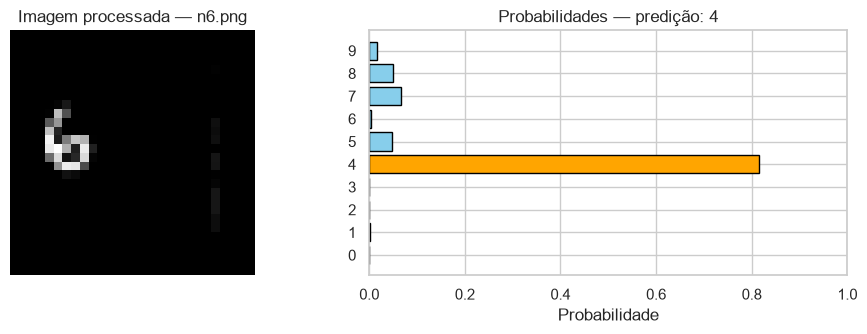

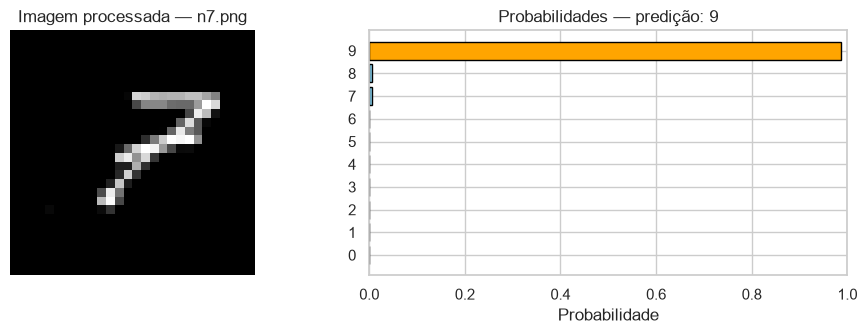

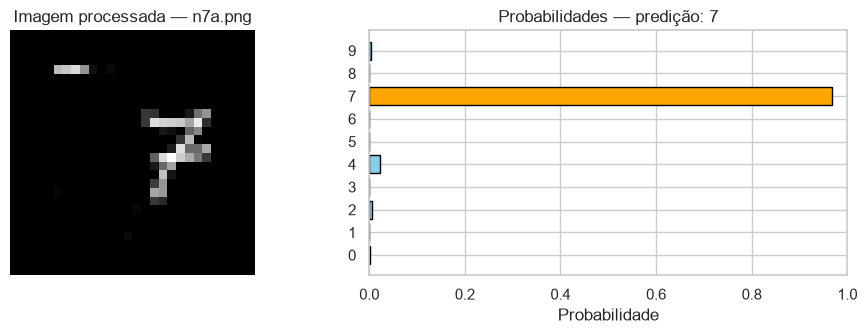

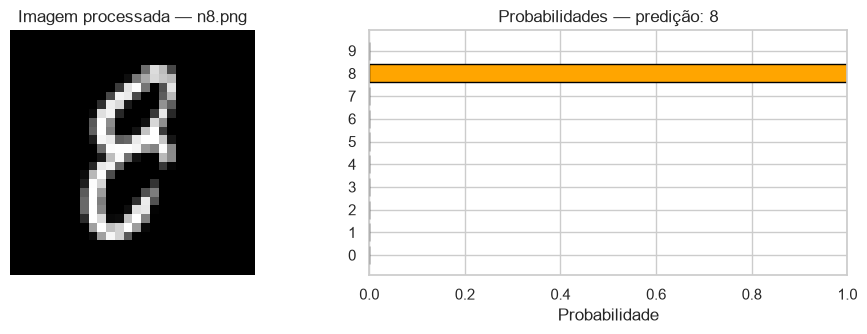

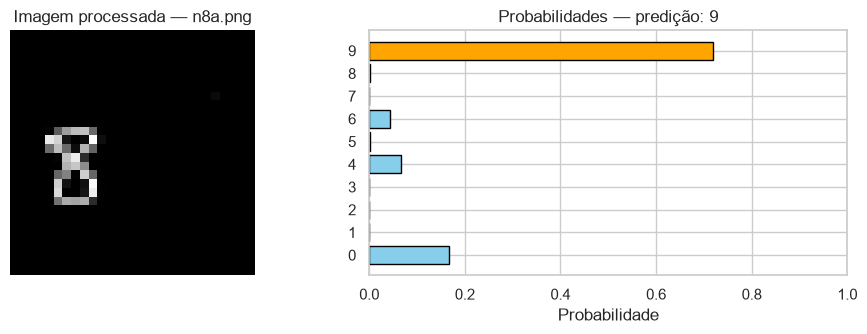

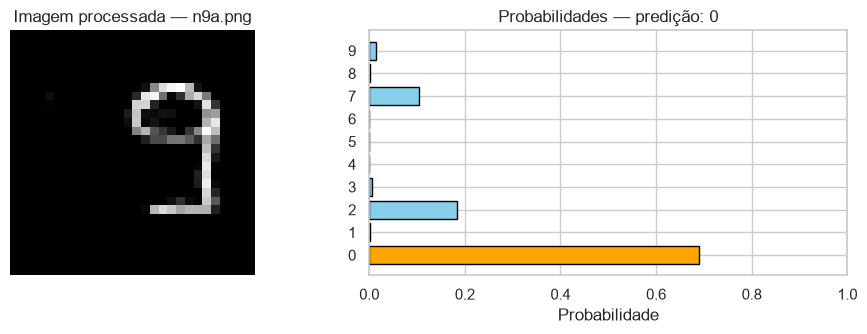

In [7]:
def predict_with_model(model_name: str, model, X_input: np.ndarray):
    if model_name == "MLP":
        probs = model.predict(X_input, verbose=0)
        preds = np.argmax(probs, axis=1)
        return preds, probs
    preds = model.predict(X_input)
    probs = model.predict_proba(X_input)
    return preds, probs


# Apenas imagens de dígitos (n0..n9*); exclui logo e outros arquivos
image_paths = sorted(
    p
    for p in list(data_dir.glob("n*.png")) + list(data_dir.glob("n*.jpg"))
    if p.is_file()
)

print(f"Imagens autorais de dígitos encontradas: {len(image_paths)}")

if not image_paths:
    print("Nenhuma imagem autoral encontrada em data/. Adicione arquivos n*.png para esta etapa.")
else:
    for image_path in image_paths:
        processed = preprocess_image_to_mnist(image_path)
        if processed is None:
            print(f"Ignorando {image_path.name}: imagem inválida ou vazia.")
            continue

        X_input = processed.reshape(1, 784)
        pred, prob = predict_with_model(best_model_name, best_model, X_input)
        pred_digit = int(pred[0])

        fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
        axes[0].imshow(processed.reshape(28, 28), cmap="gray")
        axes[0].set_title(f"Imagem processada — {image_path.name}")
        axes[0].axis("off")

        colors = ["skyblue"] * 10
        colors[pred_digit] = "orange"
        axes[1].barh(range(10), prob[0], color=colors, edgecolor="black")
        axes[1].set_yticks(range(10))
        axes[1].set_xlim(0, 1)
        axes[1].set_title(f"Probabilidades — predição: {pred_digit}")
        axes[1].set_xlabel("Probabilidade")
        plt.tight_layout()
        plt.show()


# Exportação dos artefatos

- A **MLP** é sempre exportada como `models/mnist_mlp.keras` (usada pela aplicação desktop).
- Se o melhor modelo empírico for clássico (KNN ou RF), ele também é salvo em `models/mnist_best_model.joblib`.


In [8]:
mlp_export_path = models_dir / "mnist_mlp.keras"
mlp_model.save(mlp_export_path)
print(f"MLP salva em: ./{mlp_export_path.relative_to(project_root)}")

# Cópia canônica para o app (prioridade de carregamento)
canonical_path = models_dir / "mnist_model.keras"
mlp_model.save(canonical_path)
print(f"Cópia canônica para o app: ./{canonical_path.relative_to(project_root)}")

if best_model_name != "MLP":
    best_model_path = models_dir / "mnist_best_model.joblib"
    joblib.dump(best_model, best_model_path)
    print(f"Melhor modelo clássico salvo em: ./{best_model_path.relative_to(project_root)}")
else:
    print("A MLP é o melhor modelo desta execução; artefato principal: mnist_mlp.keras / mnist_model.keras.")
print("\nPipeline concluído com sucesso.")


MLP salva em: ./models\mnist_mlp.keras
Cópia canônica para o app: ./models\mnist_model.keras
A MLP é o melhor modelo desta execução; artefato principal: mnist_mlp.keras / mnist_model.keras.

Pipeline concluído com sucesso.
